# Neural Movie Review Sentiment Analysis with Explainable Error Analysis

A walk through the whole pipeline on the Stanford Large Movie Review dataset (aclImdb): 50,000 labelled IMDB reviews.

```
RAW IMDB DATA
      |
DATA EXPLORATION  --  class balance | review length | word frequency
      |
TEXT CLEANING  ->  TEXT VECTORIZATION  ->  EMBEDDINGS
      |
TENSORFLOW CLASSIFIER  ->  model.fit()  ->  train + validation metrics
      |
TEST SET  ->  accuracy / precision / recall / F1 / ROC-AUC
      |
ERROR ANALYSIS  ->  SAVED MODEL
```

This notebook is the narrative layer; the work itself lives in `src/` and runs from the command line:

```bash
python src/download_data.py
python src/explore_data.py
python src/train.py --model pooling --epochs 15
python src/evaluate.py --model pooling
python src/predict.py --model pooling
```

Run those first: the cells below read the artifacts they leave in `reports/` and `models/`.

In [1]:
%matplotlib inline

import json
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

import config
from explore_data import load_split
from preprocess import clean_text, clean_text_python

MODEL = 'pooling'  # switch to 'bilstm' to inspect the second architecture
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


## 1-2. What is sentiment analysis, and what does the dataset contain?

Sentiment analysis is text classification where the label is the writer's attitude. Here it is binary: did this person like the film or not?

Each review is one plain-text file, and the folder it sits in (`pos` / `neg`) is the label. So the dataset has exactly two useful variables:

- `text` -> input **X**
- `label` -> target **y**, where 0 = negative and 1 = positive

IMDB only kept polarised reviews: negatives score <= 4/10 and positives >= 7/10, so there is no neutral middle. A sample of 5,000 reviews per split is loaded here for speed; `reports/eda_summary.md` has the statistics over all 50,000.

In [2]:
df = pd.concat([load_split('train', limit=2500), load_split('test', limit=2500)], ignore_index=True)
df['clean'] = df.text.map(clean_text_python)
df['word_count'] = df.clean.str.split().str.len()

print(df.shape)
df[['split', 'sentiment', 'label', 'word_count', 'text']].head(3)

(10000, 7)


,split,sentiment,label,word_count,text
0,train,neg,0,112,Story of a man who has unnatural feelings for ...
1,train,neg,0,769,Airport '77 starts as a brand new luxury 747 p...
2,train,neg,0,139,This film lacked something I couldn't put my f...


## 3. Is the dataset balanced?

This matters before trusting accuracy: on a 90/10 dataset a model that always answers "positive" scores 90% while learning nothing.

sentiment,neg,pos
split,,
test,2500,2500
train,2500,2500


sentiment  neg  pos
split              
test       0.5  0.5
train      0.5  0.5


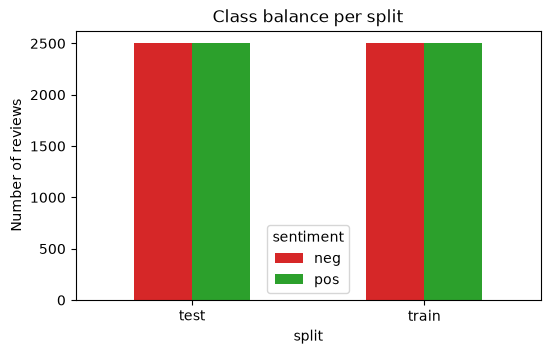

In [3]:
balance = df.pivot_table(index='split', columns='sentiment', values='file', aggfunc='count')
display(balance)
print((balance.T / balance.sum(axis=1)).T.round(3))

balance.plot(kind='bar', rot=0, color=['#d62728', '#2ca02c'], figsize=(6, 3.5))
plt.ylabel('Number of reviews')
plt.title('Class balance per split')
plt.show()

## 4. How long are the reviews?

This decides `SEQUENCE_LENGTH`: every review is padded or truncated to a fixed number of tokens, and truncation throws information away.

Mean    : 225.0 words
Median  : 169 words
Min/Max : 10 / 2459 words
90th pct: 439 words
Cut off at SEQUENCE_LENGTH=250: 28.2% of reviews


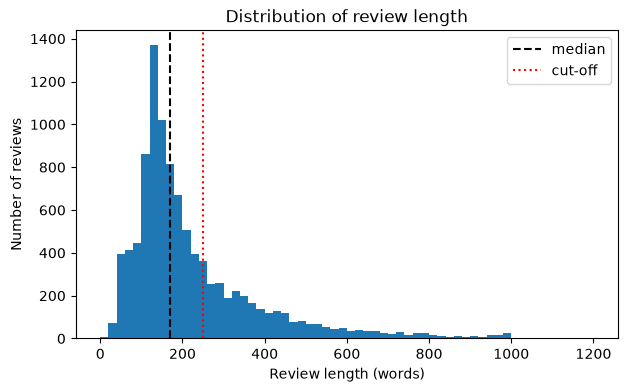

In [4]:
lengths = df.word_count.to_numpy()
print(f'Mean    : {lengths.mean():.1f} words')
print(f'Median  : {np.median(lengths):.0f} words')
print(f'Min/Max : {lengths.min()} / {lengths.max()} words')
print(f'90th pct: {np.percentile(lengths, 90):.0f} words')
print(f'Cut off at SEQUENCE_LENGTH={config.SEQUENCE_LENGTH}: {(lengths > config.SEQUENCE_LENGTH).mean():.1%} of reviews')

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=60, range=(0, 1200), color='#1f77b4')
plt.axvline(np.median(lengths), color='black', ls='--', label='median')
plt.axvline(config.SEQUENCE_LENGTH, color='red', ls=':', label='cut-off')
plt.xlabel('Review length (words)')
plt.ylabel('Number of reviews')
plt.title('Distribution of review length')
plt.legend()
plt.show()

## 5. Which tokens actually carry sentiment?

Raw frequency is useless for this ("the" wins every time), so `explore_data.py` scores each token by how much more often it appears in positive than in negative reviews:

$$\text{score}(w) = \log_2 \frac{(c^{pos}_w + 0.5)\,/\,N^{pos}}{(c^{neg}_w + 0.5)\,/\,N^{neg}}$$

Tokens below 100 occurrences are dropped so rare words cannot top the list by luck. Nothing here is hand-picked: the list is derived from the training split only.

Positive-associated tokens: edie, paulie, felix, 710, 810, matthau, 910, victoria, flawless, mildred, 1010, gandhi, astaire, superbly, perfection
Negative-associated tokens: boll, uwe, 410, 210, seagal, mst3k, 310, unwatchable, incoherent, unfunny, waste, blah, pointless, horrid, drivel


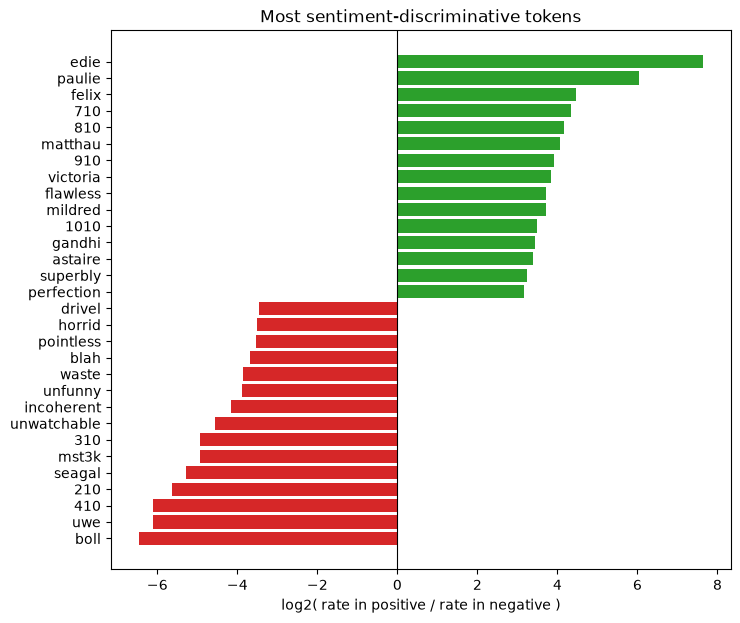

In [5]:
scores = pd.read_csv(config.REPORT_DIR / 'word_scores.csv')
top_pos = scores.head(15)
top_neg = scores.tail(15).iloc[::-1]

print('Positive-associated tokens:', ', '.join(top_pos.word))
print('Negative-associated tokens:', ', '.join(top_neg.word))

plot_df = pd.concat([top_pos, top_neg]).sort_values('log2_pos_over_neg')
plt.figure(figsize=(8, 7))
plt.barh(plot_df.word, plot_df.log2_pos_over_neg,
         color=['#d62728' if v < 0 else '#2ca02c' for v in plot_df.log2_pos_over_neg])
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('log2( rate in positive / rate in negative )')
plt.title('Most sentiment-discriminative tokens')
plt.show()

## 6. How was the text cleaned?

IMDB reviews are scraped HTML, so they are full of `<br />`. Without cleaning, the model would spend vocabulary slots on markup. `clean_text` lowercases, replaces `<br />` with a space, strips punctuation and collapses whitespace.

It is written with `tf.strings` ops and passed to `TextVectorization(standardize=...)`, so the exact same cleaning is applied during training **and** at inference time inside the saved model.

In [6]:
raw = df.text.iloc[0][:220]
print('BEFORE:', raw)
print()
print('AFTER :', clean_text(tf.constant(raw)).numpy().decode())

BEFORE: Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings o

AFTER : story of a man who has unnatural feelings for a pig starts out with a opening scene that is a terrific example of absurd comedy a formal orchestra audience is turned into an insane violent mob by the crazy chantings o


## 7-8. From text to numbers, and why embeddings?

`TextVectorization` builds a vocabulary of the 20,000 most frequent training tokens and maps each word to its index; index 0 is padding and index 1 is `[UNK]` for anything outside the vocabulary.

Those indices are arbitrary labels, not quantities: token 5000 is not "more" than token 10. An `Embedding` layer therefore replaces each index with a trainable 128-dimensional vector, learned from the sentiment task itself, so words used in similar contexts drift towards similar vectors.

The vectorizer is layer 1 of the saved model, so its learned vocabulary can be pulled straight back out of the `.keras` file.

In [7]:
model = tf.keras.models.load_model(config.MODEL_DIR / f'sentiment_model_{MODEL}.keras')
vectorizer = next(l for l in model.layers if isinstance(l, tf.keras.layers.TextVectorization))
vocab = vectorizer.get_vocabulary()

print(f'Vocabulary size: {len(vocab)}')
print('First 12 tokens:', vocab[:12])

example = 'This movie was brilliant and the acting was superb'
ids = vectorizer(tf.constant([example])).numpy()[0]
print()
print('Sentence :', example)
print('Token ids:', ids[:12].tolist())
print('Decoded  :', [vocab[i] for i in ids[:12]])

Vocabulary size: 20000
First 12 tokens: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this')]

Sentence : This movie was brilliant and the acting was superb
Token ids: [11, 17, 13, 505, 3, 2, 109, 13, 888, 0, 0, 0]
Decoded  : [np.str_('this'), np.str_('movie'), np.str_('was'), np.str_('brilliant'), np.str_('and'), np.str_('the'), np.str_('acting'), np.str_('was'), np.str_('superb'), '', '', '']


## 9-11. Architecture, sigmoid and binary cross-entropy

```
raw string -> TextVectorization -> Embedding(20000, 128) -> pooling/BiLSTM -> Dense+Dropout -> Dense(1, sigmoid)
```

- **Sigmoid** squashes the final neuron into (0, 1), which reads as P(positive). Two mutually exclusive outcomes need only one number, and the threshold 0.5 splits them.
- **Binary cross-entropy** is the matching loss: it measures the distance between that probability and the true 0/1 label, and punishes confident mistakes much harder than hesitant ones. Accuracy alone is a flat step function and gives the optimiser no gradient to follow.
- **Dropout** randomly zeroes activations during training, which stops the network relying on any single feature.
- **`mask_zero=True`** tells the pooling and LSTM layers to skip padding, so a 40-word review is not averaged against 210 zeros.

In [8]:
model.summary()

Model: "sentiment_pooling"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ review (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 250)       │          0 │ review[0][0]      │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment (Dense)   │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,711,109 (29.42 MB)

 Trainable params: 2,570,369 (9.81 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,140,740 (19.61 MB)

## 12-15. What `model.fit()` does, and is it overfitting?

Each epoch, for every batch of 32 reviews, TensorFlow: runs a forward pass to get predictions, computes the binary cross-entropy loss, backpropagates the gradient of that loss with respect to every weight, and lets Adam nudge the weights downhill. Repeat.

- **Training loss** is measured on the data the weights are being fitted to, so it almost always keeps falling.
- **Validation loss** is measured on 5,000 held-out reviews the model never trains on. The moment it starts rising while training loss still falls, the model has begun memorising rather than generalising.

`EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)` watches for exactly that and rewinds to the best epoch.

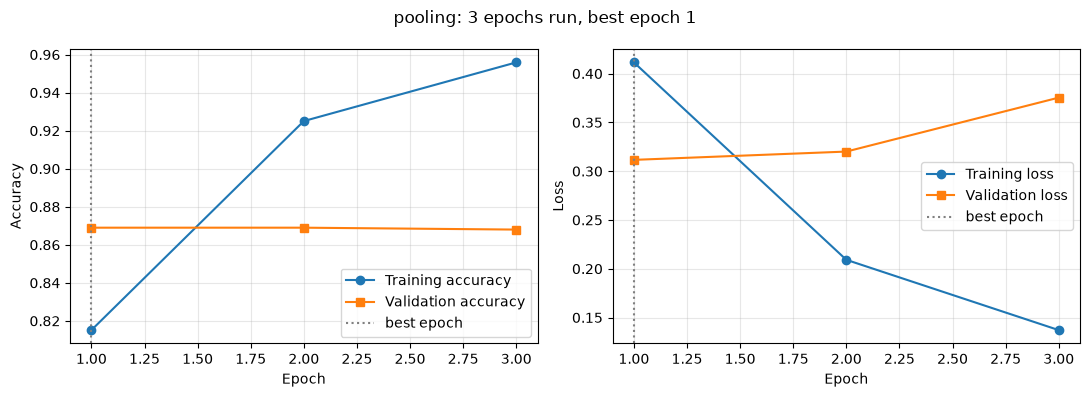

Gap at best epoch: train acc 0.8152 vs val acc 0.8690


In [9]:
run = json.loads((config.REPORT_DIR / f'history_{MODEL}.json').read_text())
hist = run['history']
epochs = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, hist['accuracy'], 'o-', label='Training accuracy')
axes[0].plot(epochs, hist['val_accuracy'], 's-', label='Validation accuracy')
axes[0].set_ylabel('Accuracy')
axes[1].plot(epochs, hist['loss'], 'o-', label='Training loss')
axes[1].plot(epochs, hist['val_loss'], 's-', label='Validation loss')
axes[1].set_ylabel('Loss')
for ax in axes:
    ax.axvline(run['best_epoch'], color='grey', ls=':', label='best epoch')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle(f"{run['model']}: {run['epochs_run']} epochs run, best epoch {run['best_epoch']}")
plt.tight_layout()
plt.show()

print(f"Gap at best epoch: train acc {run['train_accuracy']:.4f} vs val acc {run['val_accuracy']:.4f}")

## 16. Final test accuracy, and everything accuracy hides

The test set is used once, after the architecture was chosen on validation data. Tuning against the test set would quietly turn it into a second validation set and inflate the number.

- **Precision** = of the reviews called positive, how many were? (cost of false alarms)
- **Recall** = of the truly positive reviews, how many were found? (cost of misses)
- **F1** = harmonic mean of the two.
- **ROC-AUC** = ranking quality across every possible threshold, not just 0.5.

In [10]:
metrics = json.loads((config.REPORT_DIR / f'metrics_{MODEL}.json').read_text())
for key in ('test_accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'test_loss'):
    print(f'{key:<14} {metrics[key]:.4f}')

cm = pd.DataFrame(metrics['confusion_matrix'],
                  index=['Actual neg', 'Actual pos'],
                  columns=['Predicted neg', 'Predicted pos'])
display(cm)

test_accuracy  0.8532
precision      0.9117
recall         0.7822
f1             0.8420
roc_auc        0.9418
test_loss      0.3367


,Predicted neg,Predicted pos
Actual neg,11553,947
Actual pos,2722,9778


In [11]:
runs = [json.loads(p.read_text()) for p in sorted(config.REPORT_DIR.glob('metrics_*.json'))]
pd.DataFrame(runs)[['model', 'test_accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'test_loss']]

,model,test_accuracy,precision,recall,f1,roc_auc,test_loss
0,bilstm,0.85248,0.892272,0.80176,0.844598,0.936005,0.331781
1,pooling,0.85324,0.911702,0.78224,0.842024,0.941770,0.336708


## 17. What does it get wrong?

`evaluate.py` writes every mistake to `reports/misclassified_reviews_<model>.csv`, sorted by confidence, so the worst failures come first. Confidently wrong predictions are the interesting ones: they show what the model's view of language is missing.

In [12]:
wrong = pd.read_csv(config.REPORT_DIR / f'misclassified_reviews_{MODEL}.csv')
print(f"{len(wrong):,} mistakes out of {metrics['n_test']:,} test reviews")
print(wrong.groupby(['real_label', 'prediction']).size())
print(f'\nMean length of a mistake: {wrong.word_count.mean():.0f} words')

for row in wrong.head(3).itertuples():
    print(f'\n--- actual {row.real_label}, predicted {row.prediction} (score {row.score_positive:.3f})')
    print(row.review[:500].replace('<br />', ' '))

3,669 mistakes out of 25,000 test reviews
real_label  prediction
neg         pos            947
pos         neg           2722
dtype: int64

Mean length of a mistake: 266 words

--- actual neg, predicted pos (score 1.000)
Masterpiece. Carrot Top blows the screen away. Never has one movie captured the essence of the human spirit quite like "Chairman of the Board." 10/10... don't miss this instant classic.

--- actual neg, predicted pos (score 0.995)
This film has the language, the style and the attitude down ... plus greats rides from Occy (a world champ) and the great Jerry Lopez. John Philbin as Turtle has the surf pidgin down, and the surfing scenes are still the best ever. A true classic that can be seen many times. Nia Peeples is a babe, and Laird Hamilton shows the early stuff that has made him the world's number one extreme surfer.

--- actual neg, predicted pos (score 0.995)
More suspenseful, more subtle, much, much more disturbing....


## Custom reviews

The saved model takes raw strings, cleaning and vectorization included. The last two examples are deliberately hard: sarcasm and a double negative.

In [13]:
from predict import DEMO_REVIEWS, describe

scores_out = model.predict(tf.constant(DEMO_REVIEWS), verbose=0).ravel()
for review, score in zip(DEMO_REVIEWS, scores_out):
    print(f'{float(score):.4f}  {describe(float(score)):<18} {review}')

0.9966  Positive (strong)  This movie was absolutely brilliant. I loved every minute of it.
0.0000  Negative (strong)  This was boring, badly written and a complete waste of time.
0.9451  Positive (strong)  The film had some good moments but overall it was average.
0.0005  Negative (strong)  The acting was fine, but the plot made no sense whatsoever.
0.9993  Positive (strong)  What a masterpiece. I especially enjoyed wasting two hours of my life.
0.0000  Negative (strong)  Not bad at all - I expected far worse from the trailer.


## 18. What would improve it?

Ideas, roughly in order of expected payoff:

1. **Word order.** The pooling model is a bag of words: "not good at all" and "good" look similar to it. The BiLSTM variant (`--model bilstm`) reads the sequence and is the built-in comparison experiment.
2. **Bigrams.** `TextVectorization(ngrams=2)` captures "not good" as a single token without any sequential model.
3. **Pretrained embeddings or a transformer.** GloVe vectors, or fine-tuning BERT, brings outside knowledge instead of learning language from 20,000 reviews. This is where the accuracy ceiling moves.
4. **Regularisation.** The training curves show overfitting within a couple of epochs; L2 on the embedding, a smaller `EMBEDDING_DIM`, or stronger dropout delay it.
5. **Longer sequences.** Check what fraction of reviews the cut-off truncates before raising it, since cost grows with length.
6. **Threshold tuning.** If false positives and false negatives have different costs, 0.5 is not automatically the right cut.